In [1]:
# ============================================
# SMOKING DETECTION - YOLOv10 TRAINING & EVALUATION
# Optimized for Kaggle (GPU)
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import yaml
import warnings
warnings.filterwarnings('ignore')

# Install ultralytics (supports YOLOv10)
!pip install -q ultralytics

from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# ============================================
# 1. LOCATE YOUR DATASET
# ============================================
possible_paths = [
    "/kaggle/input/smoking-dataset/Smoking.v3i.yolov8",
    "/kaggle/input/smoking-esifx-3/Smoking.v3i.yolov8",
    "Smoking.v3i.yolov8",
    "/kaggle/input/datasets/roronazoromani/smoking-finalised2-dataset/Smoking.v3i.yolov8",
]

data_yaml = None
for p in possible_paths:
    test_yaml = Path(p) / "data.yaml"
    if test_yaml.exists():
        data_yaml = str(test_yaml)
        base_path = str(Path(p))
        print(f"✅ Dataset found at: {base_path}")
        break

if data_yaml is None:
    # Search inside /kaggle/input
    for root, dirs, files in os.walk("/kaggle/input"):
        if "data.yaml" in files:
            data_yaml = os.path.join(root, "data.yaml")
            base_path = os.path.dirname(data_yaml)
            print(f"✅ Found at: {base_path}")
            break

if data_yaml is None:
    raise FileNotFoundError("Could not find data.yaml. Make sure your dataset is uploaded correctly.")

# Verify single class (smoking)
with open(data_yaml, 'r') as f:
    config = yaml.safe_load(f)
    print(f"\n📄 Dataset classes: {config['names']}")
    print(f"   Number of classes: {config['nc']}")



✅ Dataset found at: /kaggle/input/datasets/roronazoromani/smoking-finalised2-dataset/Smoking.v3i.yolov8

📄 Dataset classes: ['smoking']
   Number of classes: 1


In [3]:
MODEL_NAME = 'yolov10n.pt'   # Change to 'yolov10s.pt' for better accuracy

# YOLOv10-specific hyperparameters based on research findings:
# - Batch size 16 works best for YOLOv10 (vs 32 for YOLOv8)
# - Learning rate 0.01 works best (vs 0.001 for YOLOv8)
CONFIG = {
    'data_yaml': data_yaml,
    'epochs': 100,
    'imgsz': 640,
    'batch': 16,                    # YOLOv10 optimal batch size
    'model_name': MODEL_NAME,
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'patience': 10,
    'save_period': 10,
    'project': 'smoking_detection_yolov10',
    'name': 'exp1',
    'pretrained': True,
    'optimizer': 'AdamW',           # Can also use 'SGD' with lr0=0.01
    'lr0': 0.01,                    # YOLOv10 optimal learning rate
    'weight_decay': 0.0005,
    'momentum': 0.937,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,
    'label_smoothing': 0.0,
}

print("\n" + "="*60)
print("SMOKING DETECTION - YOLOv10 TRAINING PIPELINE")
print("="*60)
print(f"Device: {CONFIG['device']}")
print(f"Model: {CONFIG['model_name']}")
print(f"Epochs: {CONFIG['epochs']}")
print(f"Batch Size: {CONFIG['batch']}")
print(f"Learning Rate: {CONFIG['lr0']}")
print(f"Data YAML: {CONFIG['data_yaml']}")



SMOKING DETECTION - YOLOv10 TRAINING PIPELINE
Device: 0
Model: yolov10n.pt
Epochs: 100
Batch Size: 16
Learning Rate: 0.01
Data YAML: /kaggle/input/datasets/roronazoromani/smoking-finalised2-dataset/Smoking.v3i.yolov8/data.yaml


In [4]:
print("\n🚀 Starting YOLOv10 model training...")

# Initialize model with pretrained weights
model = YOLO(CONFIG['model_name'])

results = model.train(
    data=CONFIG['data_yaml'],
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch'],
    device=CONFIG['device'],
    patience=CONFIG['patience'],
    save_period=CONFIG['save_period'],
    project=CONFIG['project'],
    name=CONFIG['name'],
    optimizer=CONFIG['optimizer'],
    lr0=CONFIG['lr0'],
    weight_decay=CONFIG['weight_decay'],
    momentum=CONFIG['momentum'],
    warmup_epochs=CONFIG['warmup_epochs'],
    warmup_momentum=CONFIG['warmup_momentum'],
    warmup_bias_lr=CONFIG['warmup_bias_lr'],
    label_smoothing=CONFIG['label_smoothing'],
    augment=True,
    seed=42,
    verbose=True,
)

print("\n✅ YOLOv10 Training complete!")




🚀 Starting YOLOv10 model training...
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/roronazoromani/smoking-finalised2-dataset/Smoking.v3i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=

In [5]:
# ============================================
# 4. VALIDATION
# ============================================
best_model_path = Path(f"{CONFIG['project']}/{CONFIG['name']}/weights/best.pt")
if best_model_path.exists():
    best_model = YOLO(str(best_model_path))
    val_results = best_model.val(data=CONFIG['data_yaml'])
    
    print("\n📈 YOLOv10 Validation Metrics:")
    print(f"   mAP50: {val_results.box.map50:.4f}")
    print(f"   mAP50-95: {val_results.box.map:.4f}")
    print(f"   Precision: {val_results.box.mp:.4f}")
    print(f"   Recall: {val_results.box.mr:.4f}")
else:
    print("⚠️ best.pt not found. Skipping validation.")


⚠️ best.pt not found. Skipping validation.


In [6]:
# ============================================
# 5. EXTRACT & PLOT TRAINING HISTORY
# ============================================
results_csv = Path(f"{CONFIG['project']}/{CONFIG['name']}/results.csv")
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    
    # Rename columns for clarity
    rename_map = {}
    for col in df.columns:
        if 'epoch' in col.lower():
            rename_map[col] = 'epoch'
        elif 'train/box_loss' in col:
            rename_map[col] = 'train_box_loss'
        elif 'train/cls_loss' in col:
            rename_map[col] = 'train_cls_loss'
        elif 'metrics/precision' in col:
            rename_map[col] = 'precision'
        elif 'metrics/recall' in col:
            rename_map[col] = 'recall'
        elif 'metrics/mAP50(B)' in col or 'metrics/mAP50' in col:
            rename_map[col] = 'mAP50'
        elif 'metrics/mAP50-95(B)' in col or 'metrics/mAP50-95' in col:
            rename_map[col] = 'mAP50_95'
        elif 'val/box_loss' in col:
            rename_map[col] = 'val_box_loss'
        elif 'val/cls_loss' in col:
            rename_map[col] = 'val_cls_loss'
        elif 'lr/pg0' in col:
            rename_map[col] = 'learning_rate'
    
    df = df.rename(columns=rename_map)
    
    # Find best epoch
    if 'mAP50' in df.columns:
        best_idx = df['mAP50'].idxmax()
        best_epoch = df.loc[best_idx, 'epoch']
        best_map50 = df.loc[best_idx, 'mAP50']
        print(f"\n🏆 Best YOLOv10 Model: Epoch {int(best_epoch)} with mAP50 = {best_map50:.4f}")
    
    # Plot training curves
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('YOLOv10 Smoking Detection Training', fontsize=14, fontweight='bold')
    
    # Box Loss
    if 'train_box_loss' in df.columns:
        axes[0,0].plot(df['epoch'], df['train_box_loss'], label='Train Box Loss', linewidth=2)
    if 'val_box_loss' in df.columns:
        axes[0,0].plot(df['epoch'], df['val_box_loss'], label='Val Box Loss', linewidth=2)
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Box Loss')
    axes[0,0].set_title('Box Regression Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Classification Loss
    if 'train_cls_loss' in df.columns:
        axes[0,1].plot(df['epoch'], df['train_cls_loss'], label='Train Cls Loss', linewidth=2)
    if 'val_cls_loss' in df.columns:
        axes[0,1].plot(df['epoch'], df['val_cls_loss'], label='Val Cls Loss', linewidth=2)
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Cls Loss')
    axes[0,1].set_title('Classification Loss')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Precision & Recall
    if 'precision' in df.columns:
        axes[1,0].plot(df['epoch'], df['precision'], label='Precision', color='green', linewidth=2)
    if 'recall' in df.columns:
        axes[1,0].plot(df['epoch'], df['recall'], label='Recall', color='orange', linewidth=2)
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Score')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # mAP
    if 'mAP50' in df.columns:
        axes[1,1].plot(df['epoch'], df['mAP50'], label='mAP50', color='blue', linewidth=2)
    if 'mAP50_95' in df.columns:
        axes[1,1].plot(df['epoch'], df['mAP50_95'], label='mAP50-95', color='red', linewidth=2)
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('mAP')
    axes[1,1].set_title('Mean Average Precision')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    if best_epoch is not None:
        axes[1,1].axvline(x=best_epoch, color='purple', linestyle='--', alpha=0.7, 
                          label=f'Best Epoch ({int(best_epoch)})')
        axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Display YOLOv10's saved plots
    for plot_name in ['confusion_matrix_normalized.png', 'PR_curve.png', 'F1_curve.png']:
        plot_path = Path(f"{CONFIG['project']}/{CONFIG['name']}/{plot_name}")
        if plot_path.exists():
            from PIL import Image
            plt.figure(figsize=(8,8))
            plt.imshow(Image.open(plot_path))
            plt.title(plot_name.replace('_', ' ').replace('.png', '').title())
            plt.axis('off')
            plt.show()



In [7]:
# ============================================
# 6. INFERENCE ON TEST IMAGES
# ============================================
test_images_dir = Path(base_path) / "test" / "images"
if test_images_dir.exists() and best_model_path.exists():
    print("\n🔍 Running YOLOv10 inference on test images...")
    test_model = YOLO(str(best_model_path))
    test_images = list(test_images_dir.glob("*.*"))[:6]
    
    if test_images:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        for i, img_path in enumerate(test_images):
            results = test_model(str(img_path), conf=0.25)
            img_with_boxes = results[0].plot()
            axes[i].imshow(img_with_boxes)
            axes[i].set_title(img_path.name, fontsize=8)
            axes[i].axis('off')
        plt.suptitle("YOLOv10 Smoking Detection on Test Images", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()



Found results.csv at: runs/detect/smoking_detection_yolov10/exp1/results.csv


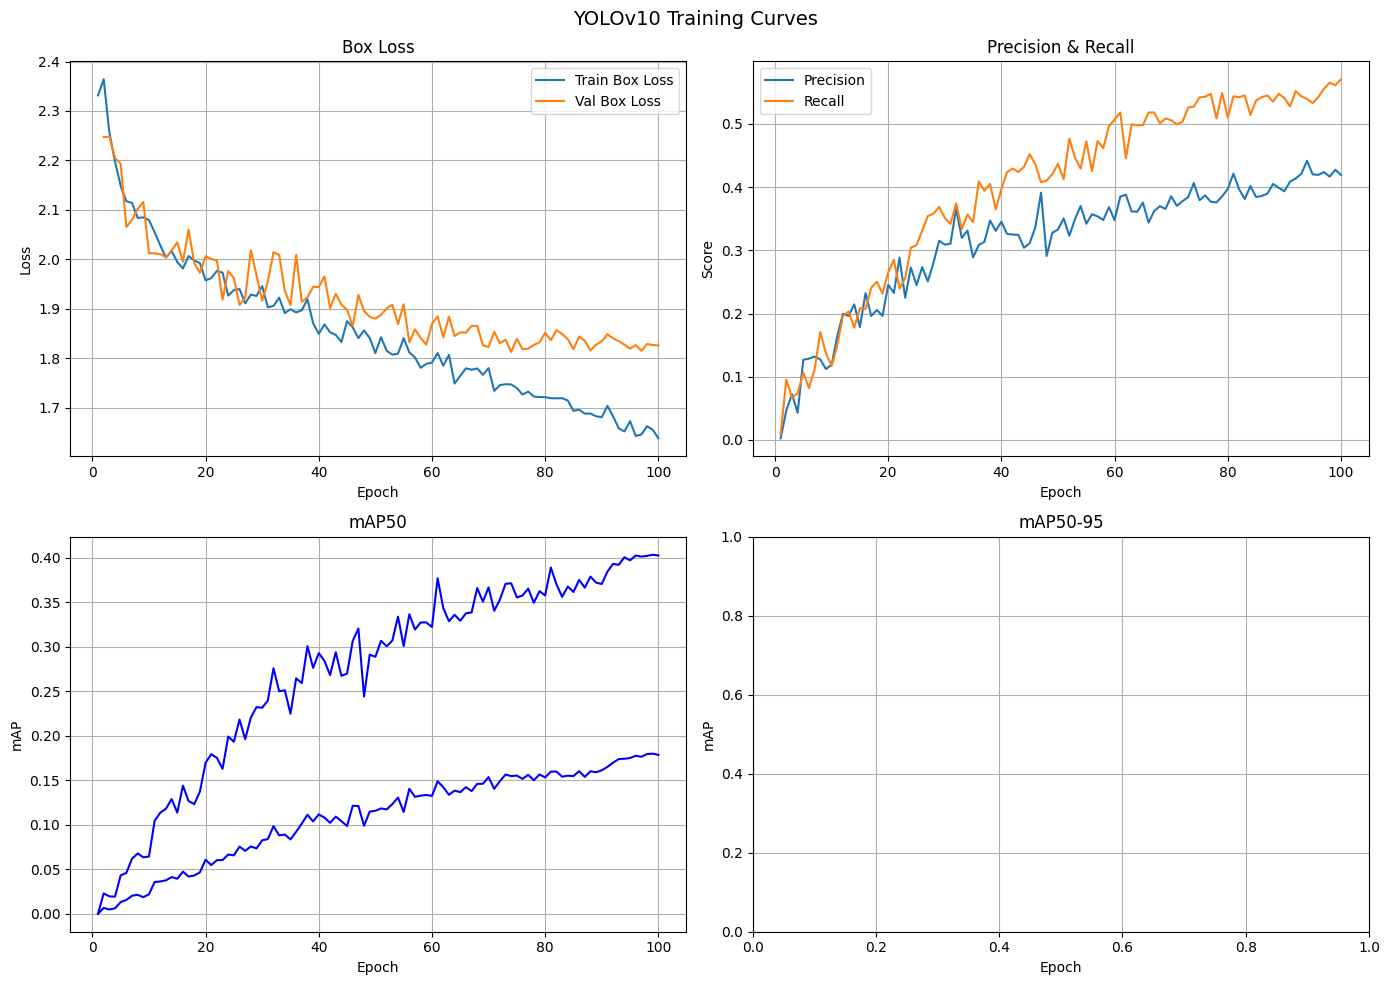

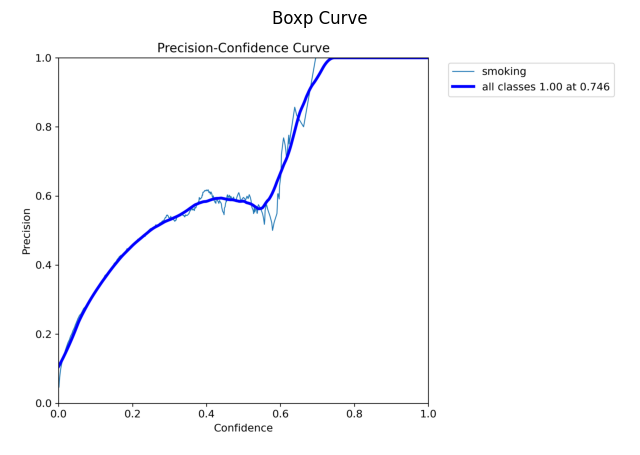

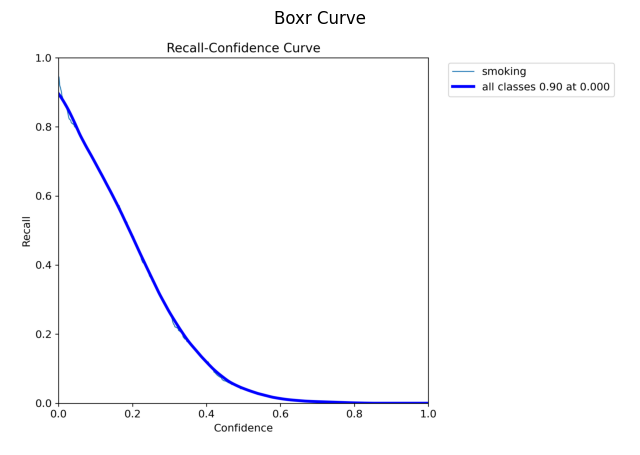

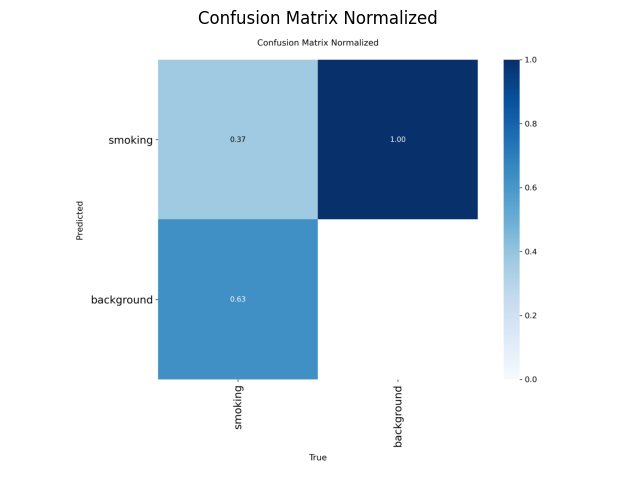

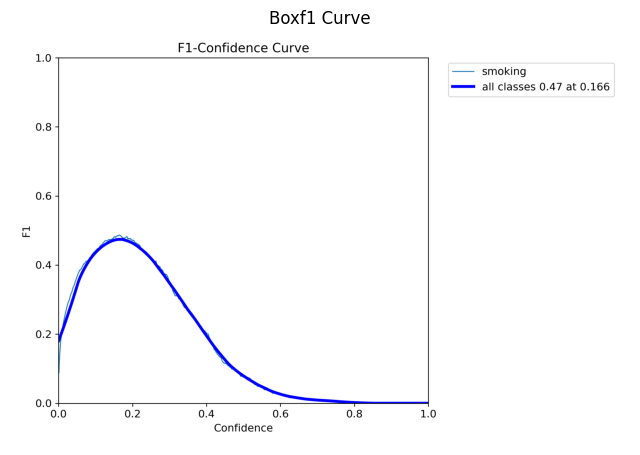

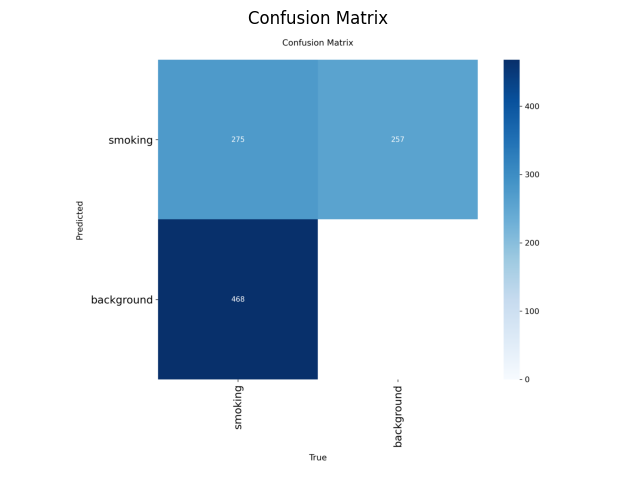

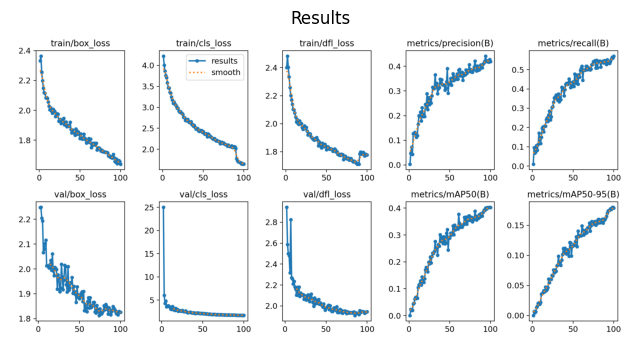

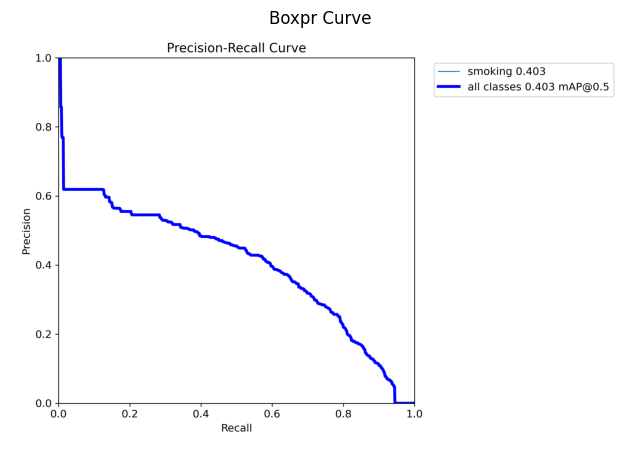

In [8]:
# ============================================
# FORCE DISPLAY OF TRAINING GRAPHS IN KAGGLE
# Run this after training completes
# ============================================

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

%matplotlib inline

results_csv = Path("smoking_detection_yolov10/exp1/results.csv")

if not results_csv.exists():
    # Try to auto-detect
    possible_paths = list(Path(".").glob("**/results.csv"))
    if possible_paths:
        results_csv = possible_paths[0]
        print(f"Found results.csv at: {results_csv}")
    else:
        raise FileNotFoundError("No results.csv found. Did training complete successfully?")

# Load data
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# Rename columns for readability
rename_map = {}
for col in df.columns:
    if 'epoch' in col.lower():
        rename_map[col] = 'epoch'
    elif 'train/box_loss' in col:
        rename_map[col] = 'train_box_loss'
    elif 'val/box_loss' in col:
        rename_map[col] = 'val_box_loss'
    elif 'metrics/precision' in col:
        rename_map[col] = 'precision'
    elif 'metrics/recall' in col:
        rename_map[col] = 'recall'
    elif 'metrics/mAP50' in col:
        rename_map[col] = 'mAP50'
    elif 'metrics/mAP50-95' in col:
        rename_map[col] = 'mAP50_95'
df = df.rename(columns=rename_map)

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("YOLOv10 Training Curves", fontsize=14)

# Box Loss
ax = axes[0,0]
if 'train_box_loss' in df:
    ax.plot(df['epoch'], df['train_box_loss'], label='Train Box Loss')
if 'val_box_loss' in df:
    ax.plot(df['epoch'], df['val_box_loss'], label='Val Box Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Box Loss')
ax.legend()
ax.grid(True)

# Precision & Recall
ax = axes[0,1]
if 'precision' in df:
    ax.plot(df['epoch'], df['precision'], label='Precision')
if 'recall' in df:
    ax.plot(df['epoch'], df['recall'], label='Recall')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall')
ax.legend()
ax.grid(True)

# mAP50
ax = axes[1,0]
if 'mAP50' in df:
    ax.plot(df['epoch'], df['mAP50'], label='mAP50', color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('mAP50')
ax.grid(True)

# mAP50-95
ax = axes[1,1]
if 'mAP50_95' in df:
    ax.plot(df['epoch'], df['mAP50_95'], label='mAP50-95', color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('mAP50-95')
ax.grid(True)

plt.tight_layout()
plt.show()  # This forces display in Kaggle

# Also display any saved PNG plots (confusion matrix, PR curve, etc.)
saved_plots_dir = results_csv.parent
for plot_file in saved_plots_dir.glob("*.png"):
    if "chart" not in plot_file.name:  # avoid results_chart.png
        from PIL import Image
        img = Image.open(plot_file)
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title(plot_file.stem.replace('_', ' ').title())
        plt.axis('off')
        plt.show()

In [ ]:
# ============================================================
# FULL TEST EVALUATION - SMOKING DETECTION
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# CONFIGURATION
# ============================================================

BEST_MODEL_PATH = (
    "results/runs/detect/smoking_detection_yolov10/exp1/weights/best.pt"
)

DATA_YAML = data_yaml   # Already loaded in notebook

# ============================================================
# LOAD MODEL
# ============================================================

print("=" * 60)
print("LOADING BEST MODEL")
print("=" * 60)

model = YOLO(BEST_MODEL_PATH)

print(f"✅ Loaded Model: {BEST_MODEL_PATH}")

# ============================================================
# TEST DATASET EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("RUNNING TEST DATASET EVALUATION")
print("=" * 60)

test_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    conf=0.25,
    plots=True,
    save_json=True,
    verbose=True
)

# ============================================================
# DISPLAY TEST METRICS
# ============================================================

precision = test_results.box.mp
recall = test_results.box.mr
map50 = test_results.box.map50
map50_95 = test_results.box.map

print("\n" + "=" * 60)
print("TEST DATASET RESULTS")
print("=" * 60)

print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"mAP@0.5       : {map50:.4f}")
print(f"mAP@0.5:0.95  : {map50_95:.4f}")

# ============================================================
# F1 SCORE
# ============================================================

f1_score = 2 * ((precision * recall) / (precision + recall + 1e-6))

print(f"F1 Score      : {f1_score:.4f}")

# ============================================================
# MICRO / MACRO METRICS
# ============================================================

# For single-class detection:
# Micro and Macro metrics are identical

print("\n" + "=" * 60)
print("MICRO / MACRO RESULTS")
print("=" * 60)

print(f"Micro Precision : {precision:.4f}")
print(f"Micro Recall    : {recall:.4f}")
print(f"Micro F1 Score  : {f1_score:.4f}")

print(f"\nMacro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1 Score  : {f1_score:.4f}")

# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "mAP@0.5",
        "mAP@0.5:0.95"
    ],
    "Value": [
        precision,
        recall,
        f1_score,
        map50,
        map50_95
    ]
})

print("\nRESULTS TABLE")
print(results_df)

# ============================================================
# SAVE RESULTS CSV
# ============================================================

results_df.to_csv("smoking_test_results.csv", index=False)

print("\n✅ CSV FILE SAVED!")

# ============================================================
# BAR CHART VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(results_df["Metric"], results_df["Value"])

plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("Smoking Detection Test Metrics")

# Add values above bars
for i, value in enumerate(results_df["Value"]):
    plt.text(i, value + 0.01, f"{value:.2f}", ha="center")

plt.show()

# ============================================================
# DISPLAY CONFUSION MATRIX
# ============================================================

cm_path = Path(
    f"{PROJECT}/{EXPERIMENT}/confusion_matrix_normalized.png"
)

if cm_path.exists():

    plt.figure(figsize=(8, 8))

    plt.imshow(Image.open(cm_path))

    plt.title("Normalized Confusion Matrix")

    plt.axis("off")

    plt.show()

# ============================================================
# DISPLAY PRECISION-RECALL CURVE
# ============================================================

pr_path = Path(
    f"{PROJECT}/{EXPERIMENT}/PR_curve.png"
)

if pr_path.exists():

    plt.figure(figsize=(8, 6))

    plt.imshow(Image.open(pr_path))

    plt.title("Precision-Recall Curve")

    plt.axis("off")

    plt.show()

# ============================================================
# DISPLAY F1 CURVE
# ============================================================

f1_path = Path(
    f"{PROJECT}/{EXPERIMENT}/F1_curve.png"
)

if f1_path.exists():

    plt.figure(figsize=(8, 6))

    plt.imshow(Image.open(f1_path))

    plt.title("F1 Curve")

    plt.axis("off")

    plt.show()

# ============================================================
# TEST IMAGE INFERENCE
# ============================================================

print("\n" + "=" * 60)
print("RUNNING TEST IMAGE INFERENCE")
print("=" * 60)

test_images_dir = Path(base_path) / "test" / "images"

test_images = list(test_images_dir.glob("*.*"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for i, img_path in enumerate(test_images):

    results = model(
        str(img_path),
        conf=0.25
    )

    plotted_image = results[0].plot()

    axes[i].imshow(plotted_image)

    axes[i].set_title(img_path.name, fontsize=8)

    axes[i].axis("off")

plt.suptitle(
    "Smoking Detection - Test Predictions",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL TEST SUMMARY")
print("=" * 60)

print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1_score:.4f}")
print(f"mAP@0.5       : {map50:.4f}")
print(f"mAP@0.5:0.95  : {map50_95:.4f}")

print("\n✅ TEST EVALUATION COMPLETED SUCCESSFULLY!")